# Customer Segmentation Analysis

## Objective
The goal of this project is to analyze customer behavior and segment customers into distinct groups using K-Means clustering. These insights can help businesses improve customer targeting and marketing strategies.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("../dataset/Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Data Cleaning

In this step, we check for:
- Missing values
- Duplicate records
- Data consistency
- Incorrect data types

In [9]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(200, 5)

In [13]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

## Observations

- No missing values were found in the dataset.
- No duplicate records were detected.
- The dataset contains both numerical and categorical features.
- Gender column contains two categories: Male and Female.
- Data quality is suitable for clustering analysis.

# Exploratory Data Analysis (EDA)

In this section, we analyze customer demographics, income distribution, and spending behavior using visualizations.

In [14]:
sns.set(style='whitegrid')

## Age Distribution Analysis

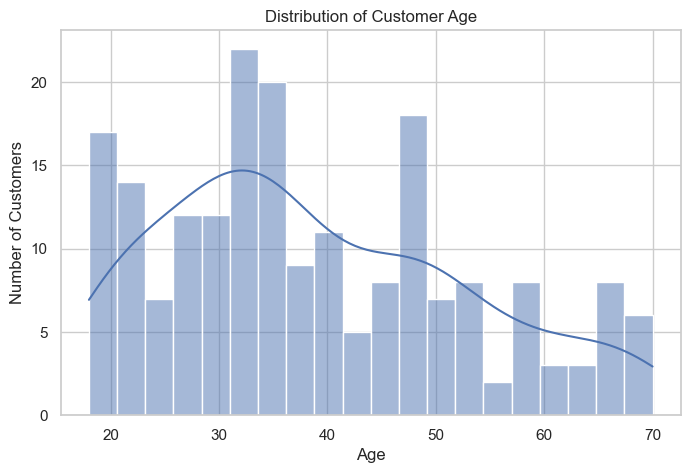

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

## Annual Income Distribution

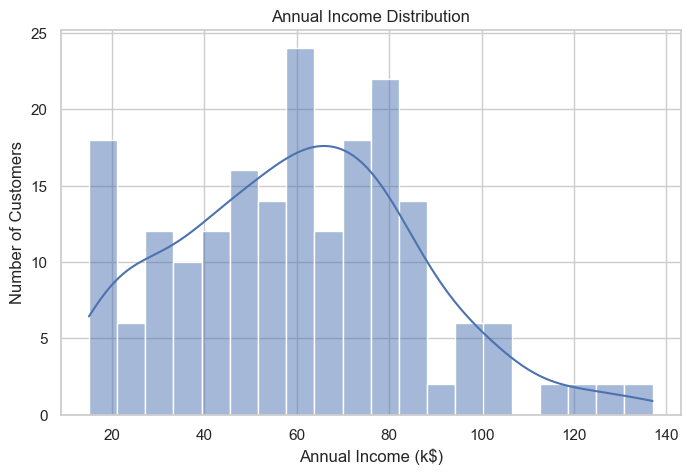

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

## Spending Score Distribution

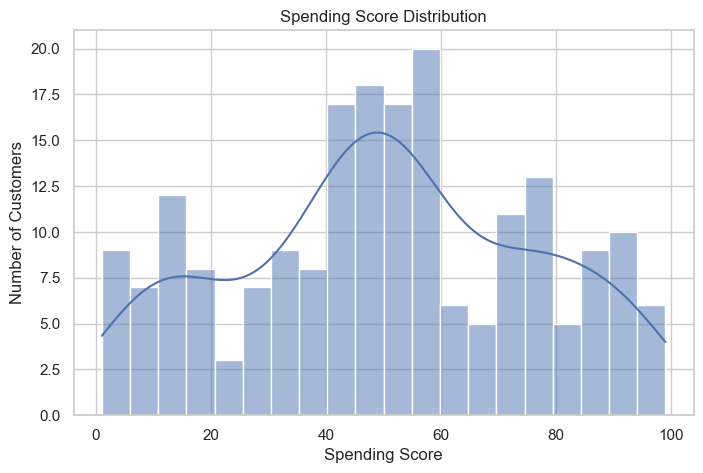

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.show()

## Gender Distribution

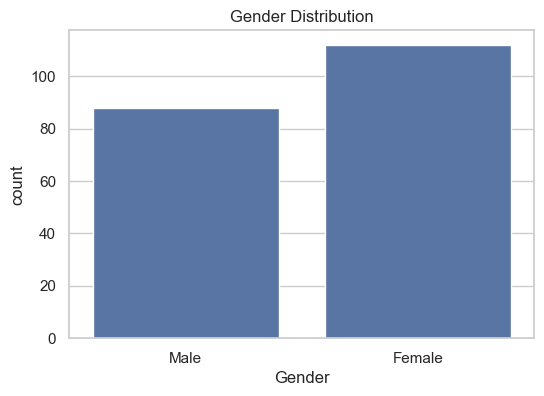

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')

plt.show()

## Annual Income vs Spending Score

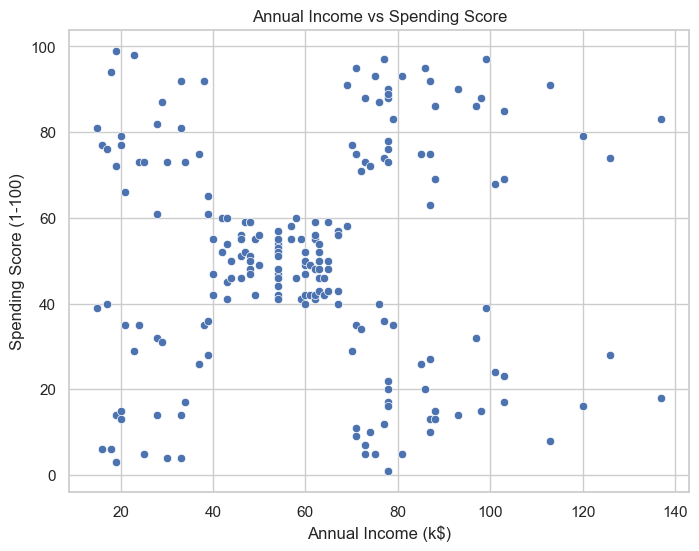

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Annual Income vs Spending Score')

plt.show()

## Correlation Heatmap

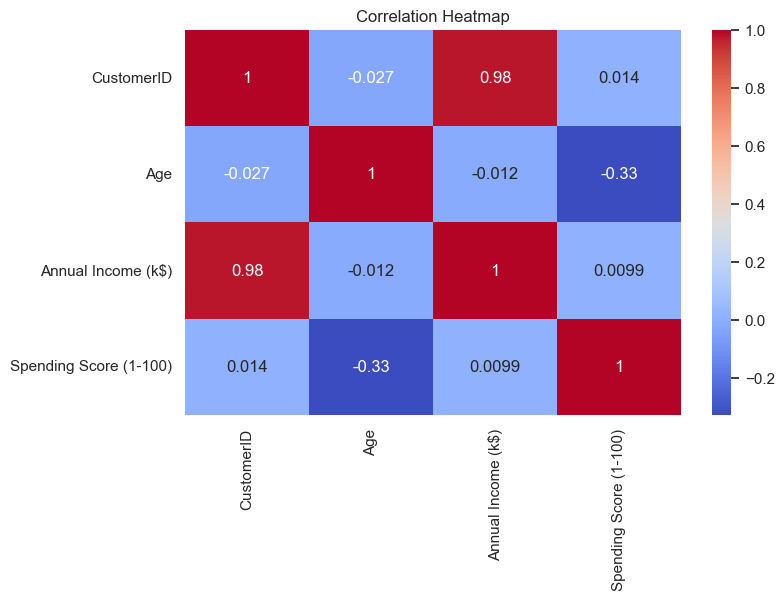

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## EDA Observations

- The age distribution shows that most customers belong to the young to middle-aged category, with fewer older customers.
- Annual income is distributed across a wide range, with a concentration around middle-income groups.
- Spending scores are spread across low, medium, and high values, indicating varying customer purchasing behaviors.
- The gender distribution shows slightly more female customers than male customers.
- The scatter plot between annual income and spending score indicates the presence of distinct customer groups, making the dataset suitable for clustering analysis.
- The correlation heatmap shows a moderate negative correlation between age and spending score, suggesting younger customers tend to spend more.
- Annual income and spending score show very low direct correlation, indicating spending habits are not solely dependent on income.

# Customer Segmentation using K-Means Clustering

In this section, we apply K-Means clustering to segment customers based on their annual income and spending behavior.

## Feature Selection

In [21]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# We are NOT using:

- CustomerID → identifier only
- Gender → categorical
- Age → not needed for initial clustering

# We use only:

- Income + Spending Behavior because businesses commonly segment customers this way.

## Elbow Method

The Elbow Method helps determine the optimal number of clusters by measuring the Within-Cluster Sum of Squares (WCSS).

In [22]:
wcss = []

for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

# What is WCSS?

- Quick understanding: WCSS = distance between data points and their cluster center
- Lower WCSS: better clustering
- But: too many clusters = overfitting.
- So we find balance.

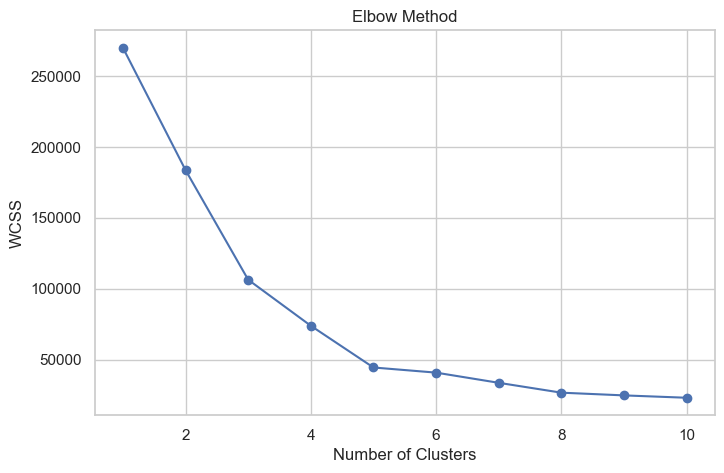

In [23]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

## Elbow Method Observations

- WCSS decreases rapidly as the number of clusters increases from 1 to 5.
- After 5 clusters, the reduction in WCSS becomes more gradual.
- The graph forms a visible “elbow” at K = 5.
- Therefore, 5 clusters are selected as the optimal number of customer segments.

In [24]:
# Why use Elbow Method?

# Answer: The Elbow Method helps identify the optimal number of clusters by finding the point where adding more clusters provides diminishing improvements in WCSS.

# K-Means Clustering Implementation

In [25]:
# Use n_clusters = 5 based on elbow method

In [26]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

In [27]:
# IMPORTANT CONCEPT

# fit_predict() does two things: trains the model, assigns cluster labels

# Example output: [0, 2, 1, 4, 3 ...] - Each number = cluster group.

In [28]:
df['Cluster'] = y_kmeans

In [29]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Customer Segments Visualization

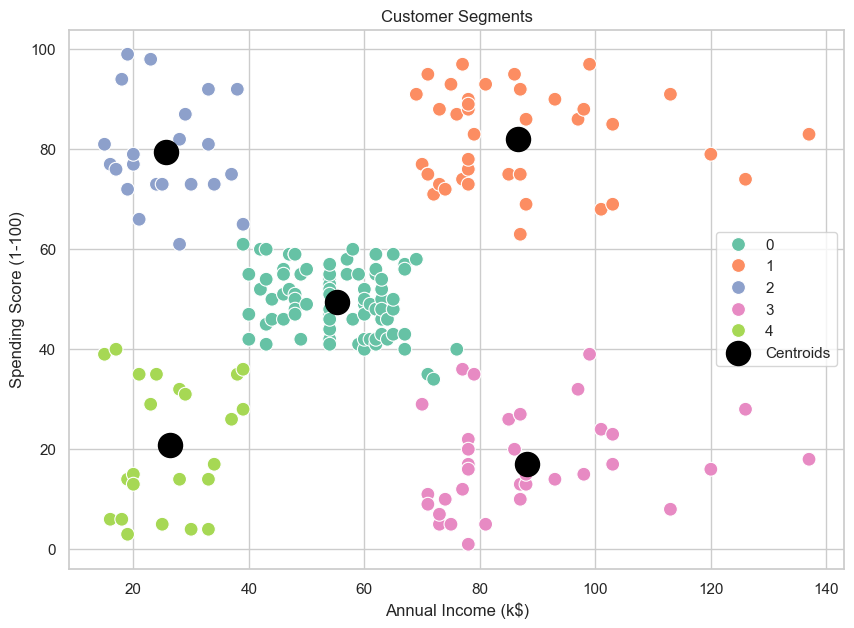

In [30]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    data=df,
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    label='Centroids'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend()

plt.show()

## Number of Customers in Each Cluster

In [31]:
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [32]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


## Clustering Observations

- Customers were successfully segmented into 5 distinct clusters using K-Means clustering.
- Cluster 1 represents high-income and high-spending customers, indicating premium or target customers for luxury marketing campaigns.
- Cluster 3 represents high-income but low-spending customers, suggesting potential customers who can be targeted using personalized offers and engagement strategies.
- Cluster 2 consists of low-income but high-spending customers, indicating impulsive or highly engaged shoppers.
- Cluster 4 represents low-income and low-spending customers, reflecting budget-conscious or less engaged customers.
- Cluster 0 contains customers with moderate income and moderate spending behavior, representing average or standard retail customers.
- The clustering visualization clearly shows well-separated customer groups, demonstrating the effectiveness of K-Means clustering for customer segmentation.
- These customer segments can help businesses improve targeted marketing, customer retention, and personalized recommendation strategies.

# Business Insights and Recommendations

## Cluster 0 — Average Customers

- Customers in this segment have moderate income and moderate spending scores.
- They represent regular retail customers with balanced purchasing behavior.

### Recommendations
- Offer loyalty programs and seasonal discounts.
- Maintain engagement through personalized recommendations.


## Cluster 1 — Premium Customers

- Customers in this segment have high income and high spending scores.
- These are high-value customers contributing significantly to revenue.

### Recommendations
- Provide exclusive memberships and premium services.
- Target with luxury product campaigns and early-access offers.


## Cluster 2 — High Spending, Low Income Customers

- Customers in this segment have lower income but high spending behavior.
- They may be highly engaged shoppers or impulsive buyers.

### Recommendations
- Promote affordable bundles and reward-based programs.
- Encourage repeat purchases through cashback and loyalty points.


## Cluster 3 — High Income, Low Spending Customers

- Customers in this segment earn high income but spend less.
- These customers have strong purchasing potential but lower engagement.

### Recommendations
- Use personalized marketing campaigns and targeted promotions.
- Improve customer engagement through premium experiences.


## Cluster 4 — Low Income, Low Spending Customers

- Customers in this segment have lower income and lower spending behavior.
- They are likely budget-conscious customers.

### Recommendations
- Offer budget-friendly products and discounts.
- Focus on value-based marketing strategies.

# Conclusion

This project successfully applied K-Means clustering to segment customers based on annual income and spending behavior.

The analysis identified distinct customer groups with varying purchasing patterns. These insights can help businesses improve targeted marketing, customer engagement, and customer retention strategies.

The project demonstrates the use of data cleaning, exploratory data analysis, clustering techniques, and business interpretation using Python and machine learning tools.